In [1]:
# install the necessay modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We will go ahead and view our dataset. We will use the train.csv and test.csv

train = pd.read_csv(r"/home/kabuga/projects/Ml-Experiment-Lab/datasets/titanic/train.csv")
test = pd.read_csv(r"/home/kabuga/projects/Ml-Experiment-Lab/datasets/titanic/test.csv")

#visualize only the first 5 rows for both the train and test

train.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
# we check the shape of the train and test set

print(f"Traing dataset {train.shape[0]} rows , {train.shape[1]} columns")
print(f"Test dataset {test.shape[0]} rows , {test.shape[1]} columns")

Traing dataset 891 rows , 12 columns
Test dataset 418 rows , 11 columns


In [5]:
# The next step is to understand our columns which we did in the data-undertanding.md

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# From the above we have
print("Name , Sex , Ticket , Carbin and Embarked are of type str")
print("===="* 20)
print("PassengerId , Survived , Pclass , SibSp , Parch are of type int")
print("===="* 20)
print("Age , Fare are of type float")

Name , Sex , Ticket , Carbin and Embarked are of type str
PassengerId , Survived , Pclass , SibSp , Parch are of type int
Age , Fare are of type float


In [7]:
# we check if our dataset has missing values
missing_values = train.isnull().sum()
print(f"Missing Values:{missing_values}")

Missing Values:PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
""""
We need to calculate the percentage missing for each column and sort from highest to lowest.
"""

percentage = (missing_values / train.shape[0]) * 100

percentage


PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [9]:
missing_df = pd.DataFrame({
    'Missing_Count' : missing_values.values ,
    'Percentage' : percentage.values
} , index= missing_values.index)
missing_df

,Missing_Count,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [10]:
# From the dataset we can see we have 3 columns with missing values.

# We need to see which method is good for imputing those values



In [11]:
"""
We will visualize each Column that has missing values.
1. Age (int)
2. Carbin and Embarked (str)
"""

'\nWe will visualize each Column that has missing values.\n1. Age (int)\n2. Carbin and Embarked (str)\n'

In [12]:
# We first perform mathematical calculations on the age column before visualizing


age_statistics = train['Age'].describe()
print(age_statistics)
#positive value = right skewed
print(f"Skewness : {train['Age'].skew():.2f}")

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
Skewness : 0.39


Text(0.5, 1.0, 'A Histogram showing the Distribution of different Ages')

Text(0.5, 1.0, 'A Histogram showing the Distribution of different Ages')

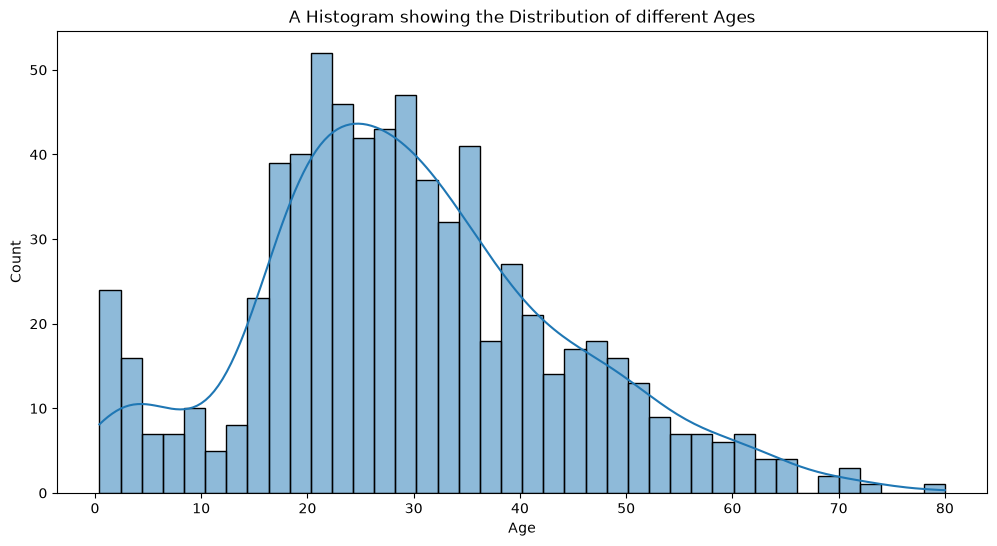

In [13]:
fig , axes = plt.subplots(figsize = (12 , 6))

sns.histplot(ax= axes , x='Age' , bins = 40 , kde= True , data= train)
axes.set_title("A Histogram showing the Distribution of different Ages")

In [14]:
"""
1. The histogram is RIGHT-SKEWED = Indicating we have mostly younger people with fewer people as the age increases.
2. The most frequent age is around 22 to 24. Its the tallest bar.Hence UNIMODAL(ONE TALLEST PEAK)
3. We can see the range of the ages is from AROUND 2 TO 80.
4. There is an infant spike of 2 years . High number of infants on the titanic compared to older children(5-15)
5. The tail smoothens from age 40 to 80
"""

'\n1. The histogram is RIGHT-SKEWED = Indicating we have mostly younger people with fewer people as the age increases.\n2. The most frequent age is around 22 to 24. Its the tallest bar.Hence UNIMODAL(ONE TALLEST PEAK)\n3. We can see the range of the ages is from AROUND 2 TO 80.\n4. There is an infant spike of 2 years . High number of infants on the titanic compared to older children(5-15)\n5. The tail smoothens from age 40 to 80\n'

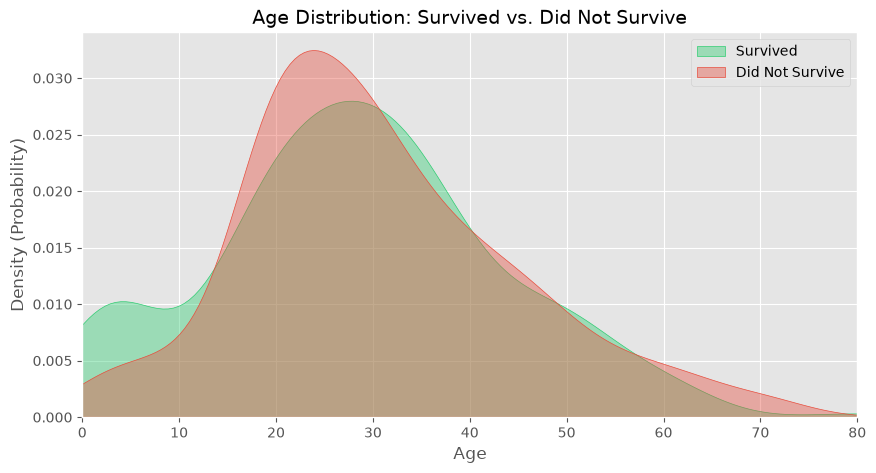

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style to match your gray grid background
plt.style.use('ggplot')
plt.figure(figsize=(10, 5))

# Plot KDE for passengers who survived (Survived == 1)
sns.kdeplot(data=train[train['Survived'] == 1], x='Age', 
            label='Survived', fill=True, color='#2ecc71', alpha=0.4)

# Plot KDE for passengers who died (Survived == 0)
sns.kdeplot(data=train[train['Survived'] == 0], x='Age', 
            label='Did Not Survive', fill=True, color='#e74c3c', alpha=0.4)

# Customize the chart
plt.title('Age Distribution: Survived vs. Did Not Survive', fontsize=14)
# Force X-axis to match the real boundaries of your dataset
plt.xlim(0, 80) 
plt.xlabel('Age')
plt.ylabel('Density (Probability)')
plt.legend()
plt.show()


In [16]:
"""
FROM THE ABOVE WE CAN DEDUCE THE FOLLOWING:
The Infant Gap: At ages 0 to 5. You will see the green line (Survived) sits significantly higher than the red line (Did Not Survive). This proves the historical fact that children were prioritized for lifeboats ("women and children first").

The Young Adult Peak: At around ages 20 to 30. The red line spikes much higher than the green line. This visually captures the tragic reality that young, able-bodied passengers (mostly 3rd class or crew) had much lower survival rates.

The Crossings: Wherever the two lines intersect is the tipping point where a passenger's age shifted from being a survival advantage to a disadvantage.

"""

'\nFROM THE ABOVE WE CAN DEDUCE THE FOLLOWING:\nThe Infant Gap: At ages 0 to 5. You will see the green line (Survived) sits significantly higher than the red line (Did Not Survive). This proves the historical fact that children were prioritized for lifeboats ("women and children first").\n\nThe Young Adult Peak: At around ages 20 to 30. The red line spikes much higher than the green line. This visually captures the tragic reality that young, able-bodied passengers (mostly 3rd class or crew) had much lower survival rates.\n\nThe Crossings: Wherever the two lines intersect is the tipping point where a passenger\'s age shifted from being a survival advantage to a disadvantage.\n\n'

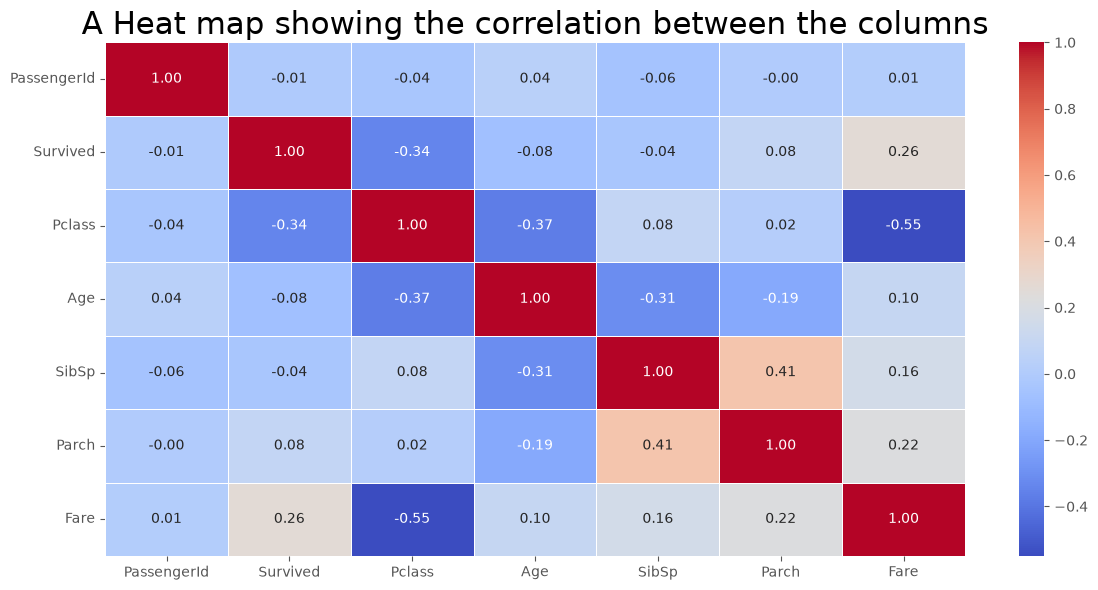

In [17]:
"""
SECOND PLOT: Is CORRELATION ANALYSIS.HOW DOES AGE CORREATE WITH OTHER NUMERICAL COLUMNS

"""

#filter to only numerical columns
corr = train.select_dtypes(include= 'number').corr()

#then plot a heat map

plt.style.use("ggplot")
fig , axes = plt.subplots(figsize = (12 , 6))

sns.heatmap(corr , ax = axes , annot= True , fmt='.2f' , cmap= 'coolwarm' , linewidths= 0.5 , linecolor= 'white' , cbar= True)
axes.set_title("A Heat map showing the correlation between the columns" , fontsize = 22)
plt.tight_layout()


In [18]:
"""
FROM THE HEATMAP:
1. AGE HAS:
    -> Positive correlation(weak) = Fare (0.10)
    -> Negative correlation = Parch(-0.19) , SibSp(-0.31) , Pclass(-0.37) , Survived(-0.08)
"""

'\nFROM THE HEATMAP:\n1. AGE HAS:\n    -> Positive correlation(weak) = Fare (0.10)\n    -> Negative correlation = Parch(-0.19) , SibSp(-0.31) , Pclass(-0.37) , Survived(-0.08)\n'

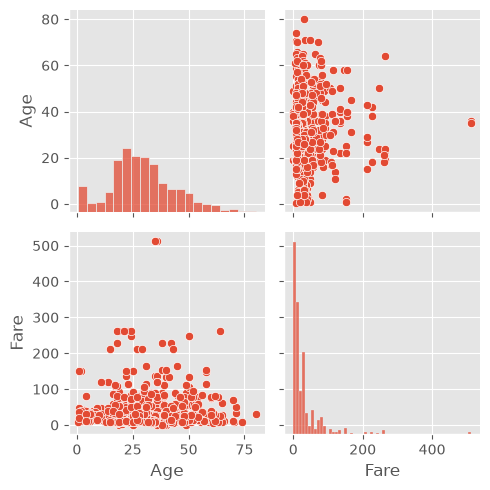

In [19]:
sns.pairplot(data= train , vars= ['Age' , 'Fare'])
plt.tight_layout()
plt.show()

In [20]:
"""
RELATIONSHIP BETWEEN AGE AND FARE :
1. There is no linear relationship between Age and Fare
"""

'\nRELATIONSHIP BETWEEN AGE AND FARE :\n1. There is no linear relationship between Age and Fare\n'

In [21]:
"""
SO FAR WE CAN DEDUCE THE FOLLOWING
1. Age Column = Right Skewed and has Outliers = We can't impute using mean. Mean is used when the column is symmetrical.
2. Mode Imputations = Best for categorical Columns but Age is Numerical
3. Age has no linear relationship with Other Numerical Columns HENCE

    ->lINEAR IMPUTATION = Not an option
    ->Random Forest = An option
    ->KNN = An Option
    BUT BEFORE WE USE ADVANCED WE TRY SIMPLER METHODS. THE REMAINING STATISTICAL METHOD IS MEDIAN

    QUESTION THAT ARISES IS : DO WE FILL WITH A GLOBAL MEDIAN??

    Not advisable because we are saying all the missing age columns to have the SAME MEDIAN. 

    THE BEST OPTION IS WE GROUP THE AGE INTO GROUPS.

    THE GROUPS :
        -> they must have a strong logical connection to age and a distinct categorical structure that splits the data into clean groups.

        -> BEST OPTIONS:
            ->Pclass (Correlation: -0.37) = This is your strongest correlation. The negative sign means as the class number gets smaller ( 1 ST class), the age gets larger (older).
            
            Why use it for the box plot: Pclass has only three distinct values (1, 2, and 3). This makes it perfect for a box plot because you will get exactly three clean boxes side-by-side to compare.

            ->The Second Best Choice: SibSp (Correlation: -0.31) or Parch (Correlation: -0.19) = The negative correlation here means passengers traveling with many siblings, spouses, parents, or children tend to be younger (large families with kids).
            
            Why use it for the box plot: These are discrete counts (0, 1, 2, 3+). Grouping by SibSp will show a massive drop in median age for passengers traveling with multiple family members compared to those traveling alone.

            TO ACHIEVE THIS WE WILL USE A BOX PLOT
"""

"\nSO FAR WE CAN DEDUCE THE FOLLOWING\n1. Age Column = Right Skewed and has Outliers = We can't impute using mean. Mean is used when the column is symmetrical.\n2. Mode Imputations = Best for categorical Columns but Age is Numerical\n3. Age has no linear relationship with Other Numerical Columns HENCE\n\n    ->lINEAR IMPUTATION = Not an option\n    ->Random Forest = An option\n    ->KNN = An Option\n    BUT BEFORE WE USE ADVANCED WE TRY SIMPLER METHODS. THE REMAINING STATISTICAL METHOD IS MEDIAN\n\n    QUESTION THAT ARISES IS : DO WE FILL WITH A GLOBAL MEDIAN??\n\n    Not advisable because we are saying all the missing age columns to have the SAME MEDIAN. \n\n    THE BEST OPTION IS WE GROUP THE AGE INTO GROUPS.\n\n    THE GROUPS :\n        -> they must have a strong logical connection to age and a distinct categorical structure that splits the data into clean groups.\n\n        -> BEST OPTIONS:\n            ->Pclass (Correlation: -0.37) = This is your strongest correlation. The negativ

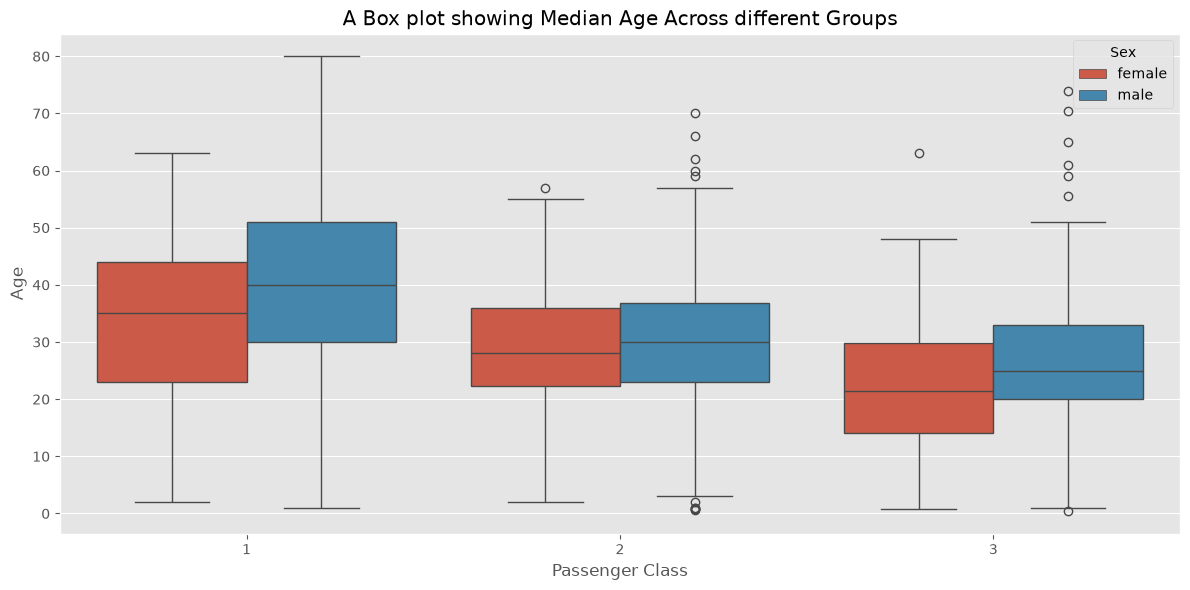

In [22]:
plt.style.use("ggplot")
fig , axes = plt.subplots(figsize= (12 , 6))
sns.boxplot(ax=axes , x= 'Pclass' , y='Age' , hue='Sex' , data=train)
axes.set_title("A Box plot showing Median Age Across different Groups")
axes.set_xlabel("Passenger Class")
axes.set_ylabel("Age")
plt.tight_layout()
plt.show()

In [23]:
"""
FROM THE BOX PLOT ABOVE: LETS BREAKDOWN (PASSENGER CLASS 1 , MALE CLASS)
1. OUTLIERS = NO Outliers indicated by dots
2. TOP WHISKER (MAXIMUM) = OLDEST NON OUTLIER PASSENGER(80 years old)
3. 75TH PERCENTILE(TOP) = AROUND 51 years of age
4. UPPER HALF ABOVE THE MIDDLE LINE = Top 25% of ages are in this zone (Ages 40 to 50)
5. MEDIAN (MIDDLE LINE) = EXACT MIDDLE AGE (40 years of age)
6. LOWER HALF BELOW THE MEDIAN LINE = Bottom 25% of ages are in this zone (Ages 30 to 40)
7. BOTTOM WHISKER(MINIMUM) = Youngest non-outlier Passenger (1 year)

WE USE THE SAME PROCEDURE TO ANALYZE THE OTHER BOXES
"""

"""
MEDIAN LINE ACROSS THE GROUPS TO DECIDE IF GLOBAL VALUE IS SAFE.

plot's conclusion: The median line drops significantly from Class 1 to Class 3. Males also skew consistently older than females in every single class.The Imputation 

Rule: Instead of filling a missing age with a blind guess, you now have 6 custom statistical numbers to use based on your plot:

Class 1 Female Impute with ~35
Class 1 Male Impute with ~40

Class 2 Female Impute with ~28
Class 2 Male Impute with ~30

Class 3 Female Impute with ~21.5
Class 3 Male Impute with ~25
"""

"\nMEDIAN LINE ACROSS THE GROUPS TO DECIDE IF GLOBAL VALUE IS SAFE.\n\nplot's conclusion: The median line drops significantly from Class 1 to Class 3. Males also skew consistently older than females in every single class.The Imputation \n\nRule: Instead of filling a missing age with a blind guess, you now have 6 custom statistical numbers to use based on your plot:\n\nClass 1 Female Impute with ~35\nClass 1 Male Impute with ~40\n\nClass 2 Female Impute with ~28\nClass 2 Male Impute with ~30\n\nClass 3 Female Impute with ~21.5\nClass 3 Male Impute with ~25\n"

In [24]:
# tHE EXACT MEDIAN VALUE PER GROUP

exact_medians = train.groupby(['Pclass' , 'Sex'])['Age'].median()
exact_medians

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [25]:
# Fill the missing values using group medians

train['Age'] = train['Age'].fillna(train.groupby(['Pclass' , 'Sex'])['Age'].transform('median'))

# check we have no missing values

print(f"Remaining missing values after imputing Age: {train['Age'].isnull().sum()}")

Remaining missing values after imputing Age: 0


In [26]:
# Check for rows with missing values in Embarked
embarked_missing = train[train['Embarked'].isna()]

# Display only the rows where Embarked is missing
embarked_missing

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [27]:
"""
tHE 2 MISSING COLUMNS:

1. HAVE THE SAME : PCLASS , TICKET , FARE , CARBIN
"""

'\ntHE 2 MISSING COLUMNS:\n\n1. HAVE THE SAME : PCLASS , TICKET , FARE , CARBIN\n'

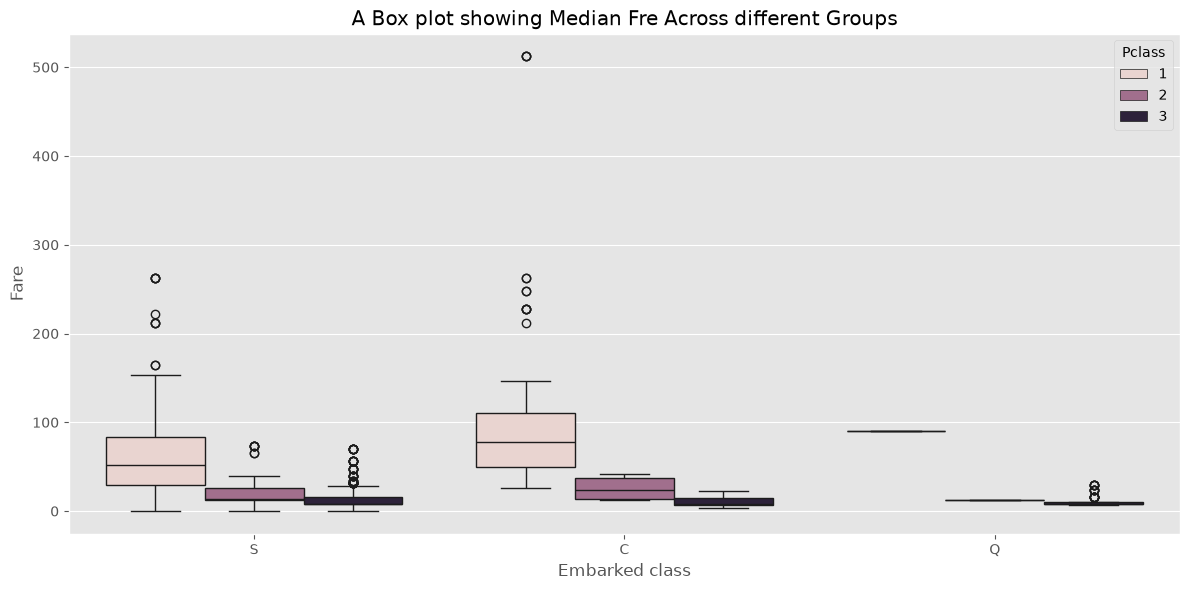

In [28]:
plt.style.use("ggplot")
fig , axes = plt.subplots(figsize= (12 , 6))
sns.boxplot(ax=axes , x= 'Embarked' , y='Fare' , hue='Pclass' , data=train)
axes.set_title("A Box plot showing Median Fre Across different Groups")
axes.set_xlabel("Embarked class")
axes.set_ylabel("Fare")
plt.tight_layout()
plt.show()

In [29]:
"""
FROM THE ABOVE WE CAN SEE THAT:

PEOPLE PAYING FARE of 80 and  and of PCLASS 1 = Are in the C embarked class

SO WE CAN FILL THEW 2 COLUMNS USING C CLASS
"""

'\nFROM THE ABOVE WE CAN SEE THAT:\n\nPEOPLE PAYING FARE of 80 and  and of PCLASS 1 = Are in the C embarked class\n\nSO WE CAN FILL THEW 2 COLUMNS USING C CLASS\n'

In [30]:
"""
The embarked column had only 2 missing values.

ITS A CATEGORICAL COLUMN: THE LOW PERCENTAGE WE HAVE 2 OPTIONS :

    -> DROP THE ROWS
    -> FILL WITH THE MODE OF THE EMBARKED COLUMN
    -> THE C EMBARKED CLASS THAT WE SAW FROM THE VISUALIZATION
"""

train['Embarked'] = train['Embarked'].fillna('C')

embarked_imputed = train[train['PassengerId'].isin([62, 830])]
embarked_imputed

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,C
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,C


In [32]:
print(train['Cabin'].str[0].value_counts())

Cabin
C    59
B    47
D    33
E    32
A    15
F    13
G     4
T     1
Name: count, dtype: int64


In [ ]:
"""
THE LAST COLUMN WE WILL IMPUTE IS CABIN
CABIN = 
"""

<Axes: xlabel='Deck', ylabel='count'>

<Axes: xlabel='Deck', ylabel='count'>

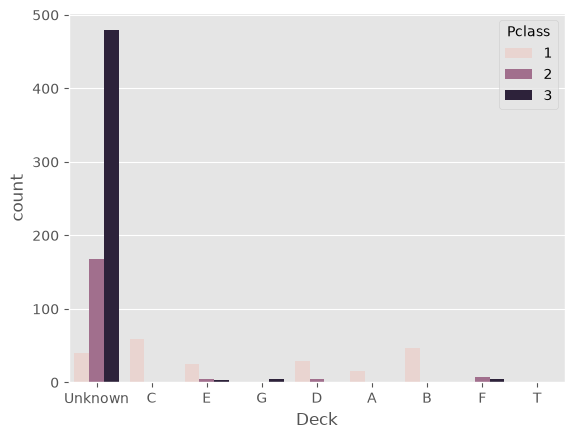

In [ ]:
train['Deck'] = train['Cabin'].fillna('Unknown').apply(lambda x: x[0] if x != 'Unknown' else x)

# Now, plot this clean 'Deck' column instead using a countplot!
sns.countplot(data=train, x='Deck', hue='Pclass')

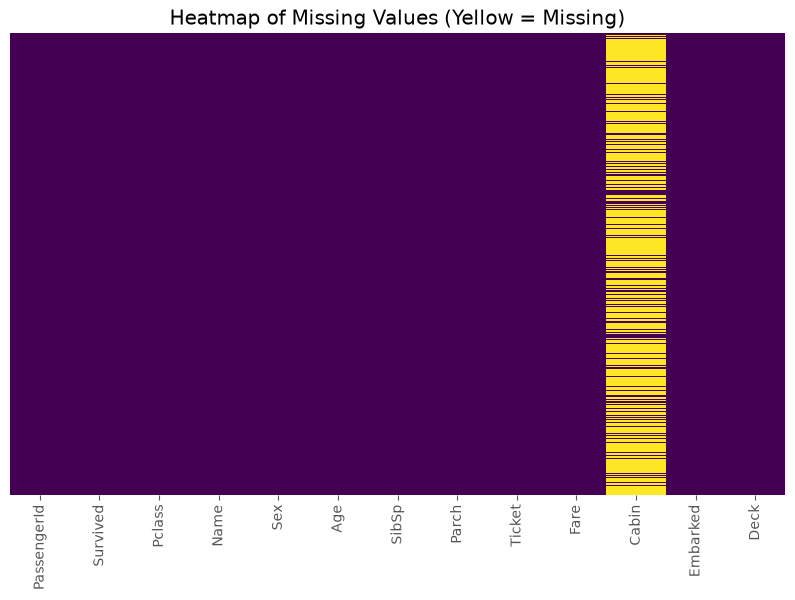

In [ ]:
plt.figure(figsize=(10, 6))
# cbar=False removes the side color scale, yticklabels=False hides row numbers
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap of Missing Values (Yellow = Missing)')
plt.show()

In [ ]:
"""
BASED ON THE 2 VISUALISATIONS OF THE CABIN COLUMN

OUR GOAL: TO HANDLE THE MISSING CABIN VALUES

1. COUNT PLOT

-> The rows with missing values(UNKNOWN) = HAVE A STRONG RELATIONSHIP WITH PCLASS(3)
-> The rows with actual cabin values(KNOWN) = DOMINATED BY PCLASS(1) , FOLLOWED BY PCLASS(2) , THEN PCLASS(3)

WHAT THIS MEANS: 

    -> The missingness being ties to class 3 we can't use a standard imputation method = MODE (FILL ALL MISSING CABIN VALUES WITH CABIN C)
    -> , you would accidentally assign cheap Class 3 passengers to expensive Class 1/2 decks, which would completely corrupt your data's logic.
"""

"""
STRATEGY 1

Create an Explicit 'M' (Missing) or 'U' (Unknown) Category

Instead of treating the blanks as missing data to fill with existing values, you treat Missingness itself as a distinct category.

You keep your engineered Deck column.Leave the missing values as 'M' or 'Unknown'.

When your machine learning model runs, it will learn that Deck = 'Unknown' is a massive indicator that the passenger was in Class 3 and had a lower survival rate.


STRATEGY 2 :

Since your heatmap shows that Cabin is the only major column with this structural vacancy now (since you fixed Age and Embarked)

you can convert it into a simple 1 or 0 flag:

1= fOR PASSENGERS WITH A CABIN VALUE
0 = PASWENGERS WITH NO CABIN VALUE
"""

"\nSTRATEGY 1\n\nCreate an Explicit 'M' (Missing) or 'U' (Unknown) Category\n\nInstead of treating the blanks as missing data to fill with existing values, you treat Missingness itself as a distinct category.\n\nYou keep your engineered Deck column.Leave the missing values as 'M' or 'Unknown'.\n\nWhen your machine learning model runs, it will learn that Deck = 'Unknown' is a massive indicator that the passenger was in Class 3 and had a lower survival rate.\n\n\nSTRATEGY 2 :\n\nSince your heatmap shows that Cabin is the only major column with this structural vacancy now (since you fixed Age and Embarked)\n\nyou can convert it into a simple 1 or 0 flag:\n\n1= fOR PASSENGERS WITH A CABIN VALUE\n0 = PASWENGERS WITH NO CABIN VALUE\n"

In [34]:
# wE USE STRATEGY 1

# 1. Extract the Deck letter and fill missing values with 'M'
train['Deck'] = train['Cabin'].str[0].fillna('M')

# 2. Drop the original messy Cabin column
train = train.drop(columns=['Cabin'])

# 3. Double-check that your dataset no longer has missing values here
print(train['Deck'].value_counts())


Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


In [35]:
#  We now confirm that we gave null values

train_cleaned = train.isnull().sum()
train_cleaned

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Deck           0
dtype: int64